In [4]:
# Install Required Libraries
!pip install einops albumentations torchinfo

In [5]:

# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [6]:
#Import Libraries
import numpy as np
import matplotlib.pyplot as plt

In [7]:
#Create Sample Image
np.random.seed(42)

# One RGB image
image = np.random.rand(1, 3, 32, 32)

print("Image Shape:", image.shape)

Image Shape: (1, 3, 32, 32)


In [8]:
#Create Convolution Filters
out_channels = 8
in_channels = 3
kernel_size = 3

filters = np.random.randn(
    out_channels,
    in_channels,
    kernel_size,
    kernel_size
)

print("Filter Shape:", filters.shape)

Filter Shape: (8, 3, 3, 3)


In [9]:
#Padding Function
def zero_pad(image, pad):

    return np.pad(
        image,
        (
            (0,0),
            (0,0),
            (pad,pad),
            (pad,pad)
        ),
        mode='constant'
    )


In [10]:
#im2col Function
def im2col(images, kernel_size, stride=1, padding=0):

    images = zero_pad(images, padding)

    N, C, H, W = images.shape

    out_h = (H-kernel_size)//stride + 1
    out_w = (W-kernel_size)//stride + 1

    cols = []

    for y in range(out_h):

        for x in range(out_w):

            patch = images[
                :,
                :,
                y*stride:y*stride+kernel_size,
                x*stride:x*stride+kernel_size
            ]

            cols.append(
                patch.reshape(N,-1)
            )

    cols = np.stack(cols,axis=1)

    return cols

In [11]:
#Convert Image into Columns
columns = im2col(
    image,
    kernel_size=3,
    stride=1,
    padding=1
)

print(columns.shape)

(1, 1024, 27)


In [12]:

#Flatten Filters
filter_matrix = filters.reshape(
    out_channels,
    -1
)

print(filter_matrix.shape)

(8, 27)


In [13]:

#Vectorized Convolution
output = np.matmul(
    columns,
    filter_matrix.T
)

print(output.shape)

(1, 1024, 8)


In [14]:
#Convert Back to Feature Maps
output = output.reshape(
    1,
    32,
    32,
    out_channels
)

output = np.transpose(
    output,
    (0,3,1,2)
)

print(output.shape)

(1, 8, 32, 32)


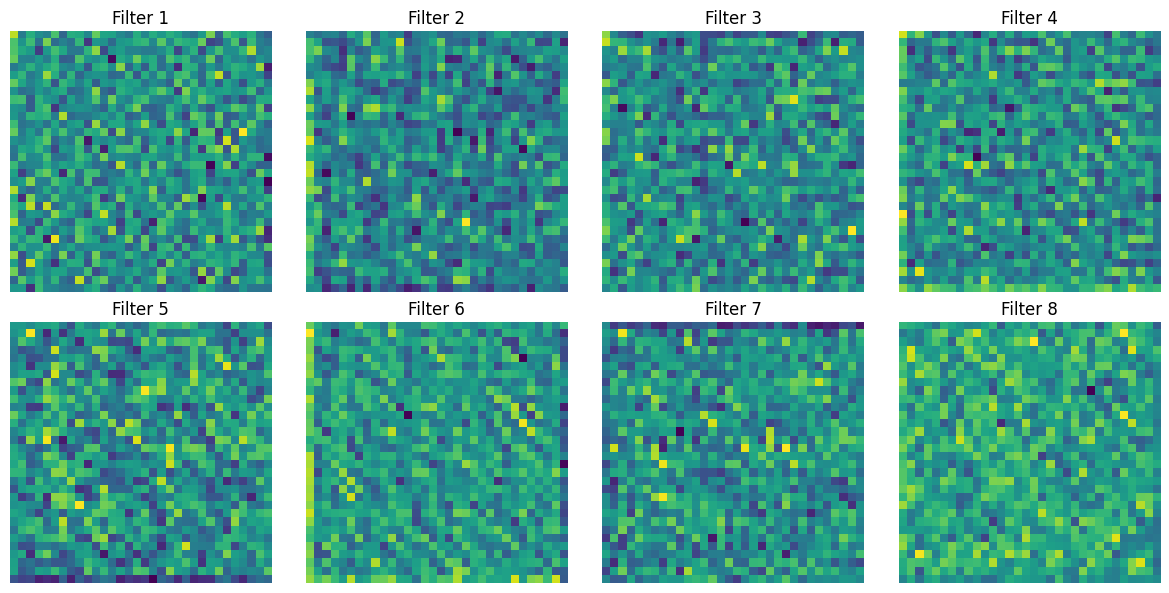

In [15]:
#Visualize Feature Maps
fig, axes = plt.subplots(2,4, figsize=(12,6))

for i in range(8):

    ax = axes[i//4, i%4]

    ax.imshow(
        output[0,i],
        cmap="viridis"
    )

    ax.set_title(f"Filter {i+1}")

    ax.axis("off")

plt.tight_layout()

plt.show()

In [16]:
#Verify Output Dimensions
print("Input Shape :", image.shape)

print("Kernel Size :", kernel_size)

print("Output Shape:", output.shape)

Input Shape : (1, 3, 32, 32)
Kernel Size : 3
Output Shape: (1, 8, 32, 32)


In [17]:
#Summary
print("""
Task 3 Completed Successfully!

Pure NumPy implementation
im2col transformation
Matrix multiplication-based convolution
Multi-channel input
Multiple output filters
Configurable padding
Configurable stride
Feature map visualization
""")


Task 3 Completed Successfully!

Pure NumPy implementation
im2col transformation
Matrix multiplication-based convolution
Multi-channel input
Multiple output filters
Configurable padding
Configurable stride
Feature map visualization

